# Análisis de Regresión — Ofertas de Juegos
Este notebook carga datos del proyecto ETL, prepara un modelo de regresión simple y analiza el desempeño del modelo.

In [1]:
import os
from dotenv import load_dotenv
import sys
sys.path.insert(0, os.path.abspath(os.path.join("..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

load_dotenv()
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv('/home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/deals.csv')

graficas_dir = '/home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas'
os.makedirs(graficas_dir, exist_ok=True)
df.head()

,titulo,precio_oferta,precio_normal,ahorro_porcentaje,store_id,rating_steam,metacritic,fecha_extraccion
0,Asteroid Core,0.49,9.99,95.095095,1,66,0,2026-03-13 14:42:26.789026
1,Just Move:Clean City Messy Battle,0.79,15.99,95.059412,1,0,0,2026-03-13 14:42:26.789034
2,Dead End Job,0.84,16.99,95.055915,1,72,0,2026-03-13 14:42:26.789035
3,Jad,0.84,16.99,95.055915,1,76,0,2026-03-13 14:42:26.789036
4,Brother Wings,0.99,19.99,95.047524,1,70,0,2026-03-13 14:42:26.789038


In [2]:
df.info()

print('\nNulos por columna:')
print(df.isnull().sum())

print('\nDimensiones del dataset:')
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   titulo             30 non-null     object 
 1   precio_oferta      30 non-null     float64
 2   precio_normal      30 non-null     float64
 3   ahorro_porcentaje  30 non-null     float64
 4   store_id           30 non-null     int64  
 5   rating_steam       30 non-null     int64  
 6   metacritic         30 non-null     int64  
 7   fecha_extraccion   30 non-null     object 
dtypes: float64(3), int64(3), object(2)
memory usage: 2.0+ KB

Nulos por columna:
titulo               0
precio_oferta        0
precio_normal        0
ahorro_porcentaje    0
store_id             0
rating_steam         0
metacritic           0
fecha_extraccion     0
dtype: int64

Dimensiones del dataset:
(30, 8)


In [3]:
df['precio_oferta'] = pd.to_numeric(df['precio_oferta'], errors='coerce')
df['precio_normal'] = pd.to_numeric(df['precio_normal'], errors='coerce')
df['ahorro_porcentaje'] = pd.to_numeric(df['ahorro_porcentaje'], errors='coerce')
df['rating_steam'] = pd.to_numeric(df['rating_steam'], errors='coerce')
df['metacritic'] = pd.to_numeric(df['metacritic'], errors='coerce')
df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'], errors='coerce')

print(df.dtypes)

titulo                       object
precio_oferta               float64
precio_normal               float64
ahorro_porcentaje           float64
store_id                      int64
rating_steam                  int64
metacritic                    int64
fecha_extraccion     datetime64[ns]
dtype: object


In [4]:
df[['precio_oferta', 'precio_normal', 'ahorro_porcentaje', 'rating_steam', 'metacritic']].describe()

,precio_oferta,precio_normal,ahorro_porcentaje,rating_steam,metacritic
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1.056667,21.323333,95.046685,75.000000,4.700000
std,0.223735,4.474705,0.011582,19.807696,17.886905
min,0.490000,9.990000,95.031677,0.000000,0.000000
25%,0.990000,19.990000,95.040392,68.000000,0.000000
50%,0.990000,19.990000,95.047524,72.500000,0.000000
75%,1.177500,23.740000,95.047524,89.750000,0.000000
max,1.490000,29.990000,95.095095,100.000000,71.000000


In [5]:
df['ahorro_calculado'] = ((df['precio_normal'] - df['precio_oferta']) / df['precio_normal']) * 100

comparacion = df[['precio_oferta', 'precio_normal', 'ahorro_porcentaje', 'ahorro_calculado']].copy()
comparacion['diferencia'] = comparacion['ahorro_porcentaje'] - comparacion['ahorro_calculado']

comparacion.head(10)

,precio_oferta,precio_normal,ahorro_porcentaje,ahorro_calculado,diferencia
0,0.49,9.99,95.095095,95.095095,-9.509509e-08
1,0.79,15.99,95.059412,95.059412,-1.325829e-07
2,0.84,16.99,95.055915,95.055915,-2.442613e-07
3,0.84,16.99,95.055915,95.055915,-2.442613e-07
4,0.99,19.99,95.047524,95.047524,2.381190e-07
5,0.99,19.99,95.047524,95.047524,2.381190e-07
6,0.99,19.99,95.047524,95.047524,2.381190e-07
7,0.99,19.99,95.047524,95.047524,2.381190e-07
8,0.99,19.99,95.047524,95.047524,2.381190e-07
9,0.99,19.99,95.047524,95.047524,2.381190e-07


In [6]:
print('Diferencia promedio entre ahorro real y calculado:')
print(comparacion['diferencia'].mean())

print('\nMáxima diferencia absoluta:')
print(comparacion['diferencia'].abs().max())

Diferencia promedio entre ahorro real y calculado:
6.142149165574059e-08

Máxima diferencia absoluta:
2.4426134359600837e-07


Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/hist_precio_oferta.png


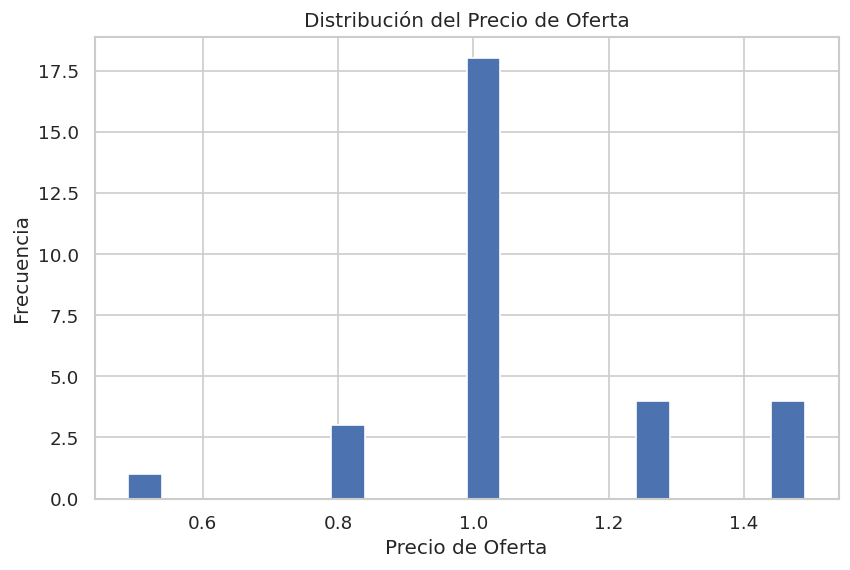

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['precio_oferta'].dropna(), bins=20)
plt.title('Distribución del Precio de Oferta')
plt.xlabel('Precio de Oferta')
plt.ylabel('Frecuencia')
filename = os.path.join(graficas_dir, 'hist_precio_oferta.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/hist_ahorro_porcentaje.png


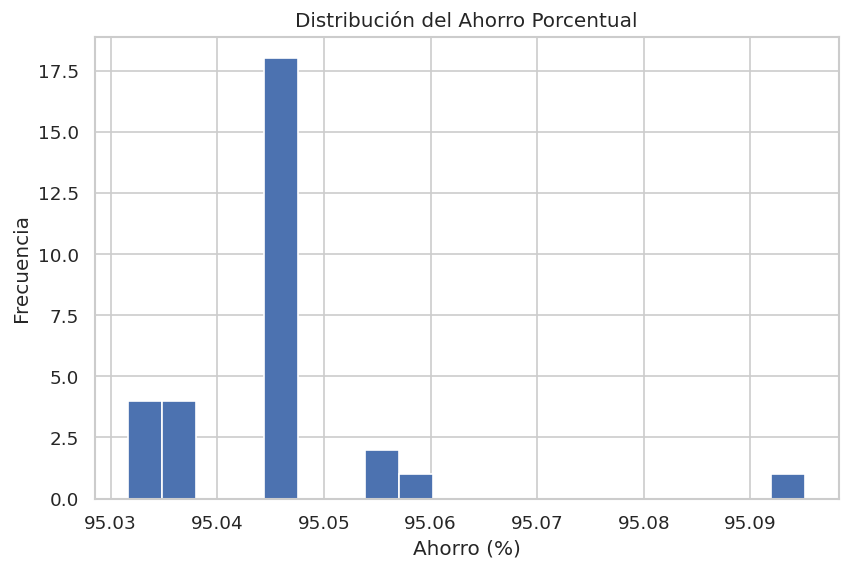

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['ahorro_porcentaje'].dropna(), bins=20)
plt.title('Distribución del Ahorro Porcentual')
plt.xlabel('Ahorro (%)')
plt.ylabel('Frecuencia')
filename = os.path.join(graficas_dir, 'hist_ahorro_porcentaje.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/box_precio_oferta.png


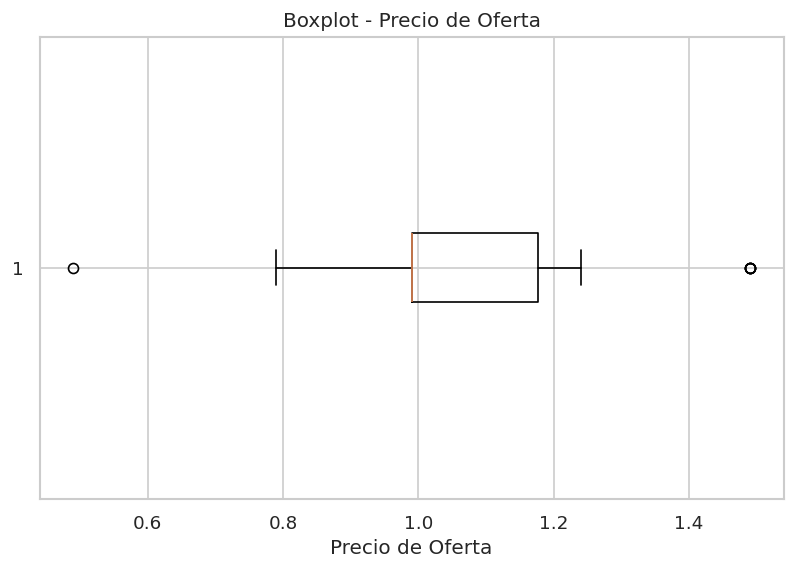

In [9]:
plt.figure(figsize=(8,5))
plt.boxplot(df['precio_oferta'].dropna(), vert=False)
plt.title('Boxplot - Precio de Oferta')
plt.xlabel('Precio de Oferta')
filename = os.path.join(graficas_dir, 'box_precio_oferta.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/scatter_precio_normal_vs_oferta.png


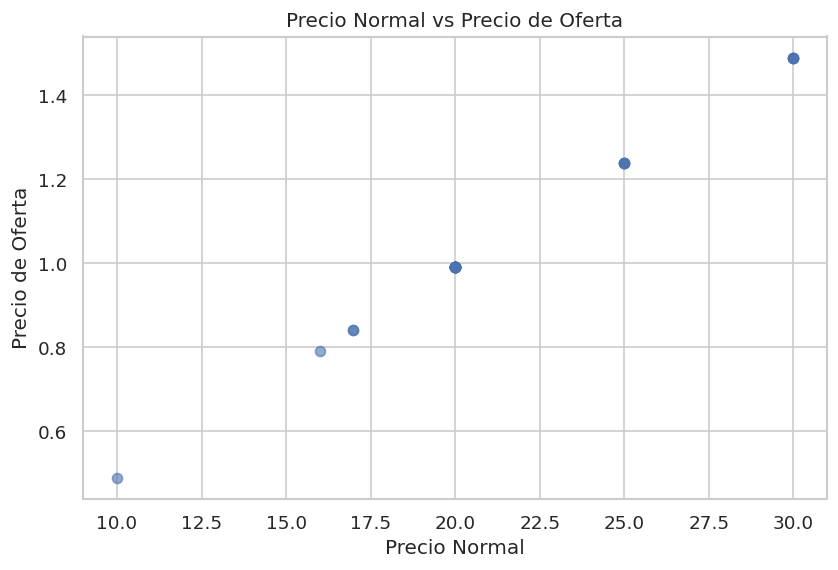

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['precio_normal'], df['precio_oferta'], alpha=0.6)
plt.title('Precio Normal vs Precio de Oferta')
plt.xlabel('Precio Normal')
plt.ylabel('Precio de Oferta')
filename = os.path.join(graficas_dir, 'scatter_precio_normal_vs_oferta.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/heatmap_correlacion.png


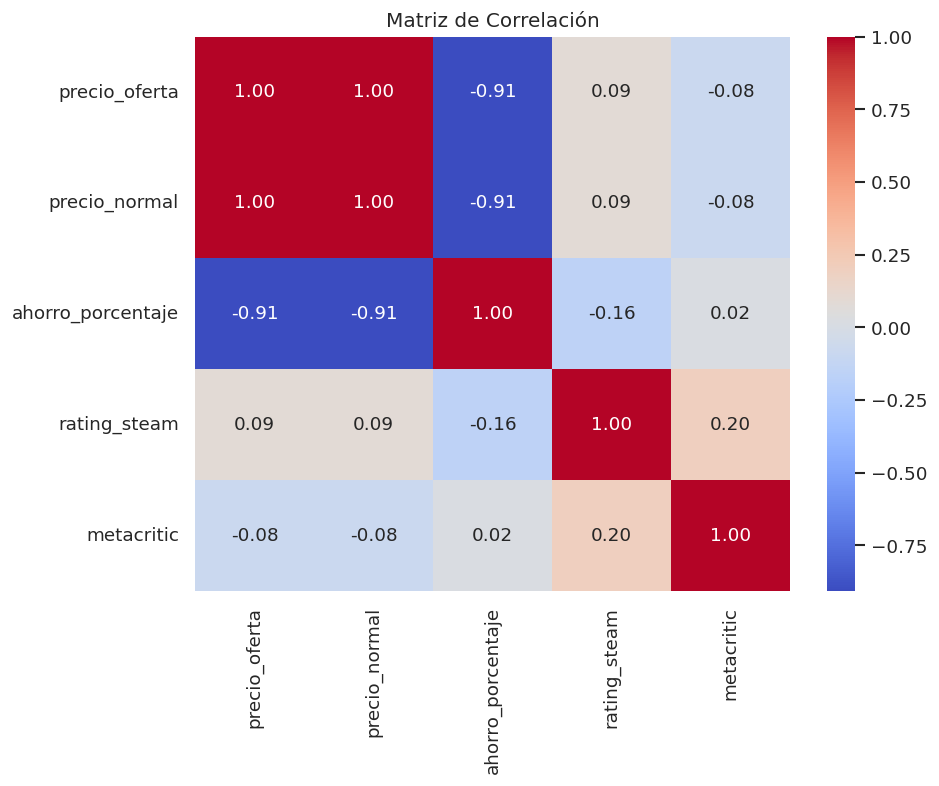

In [11]:
corr = df[['precio_oferta', 'precio_normal', 'ahorro_porcentaje', 'rating_steam', 'metacritic']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación')
filename = os.path.join(graficas_dir, 'heatmap_correlacion.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

In [12]:
top_ahorro = df.sort_values(by='ahorro_porcentaje', ascending=False)[
    ['titulo', 'precio_oferta', 'precio_normal', 'ahorro_porcentaje']
].head(10)

top_ahorro

,titulo,precio_oferta,precio_normal,ahorro_porcentaje
0,Asteroid Core,0.49,9.99,95.095095
1,Just Move:Clean City Messy Battle,0.79,15.99,95.059412
2,Dead End Job,0.84,16.99,95.055915
3,Jad,0.84,16.99,95.055915
4,Brother Wings,0.99,19.99,95.047524
5,Galaxy Girls,0.99,19.99,95.047524
6,Ultimate Fishing Simulator,0.99,19.99,95.047524
7,Deadliest Catch: The Game,0.99,19.99,95.047524
8,Helheim Hassle,0.99,19.99,95.047524
9,Ultimate Fishing Simulator 2,0.99,19.99,95.047524


In [13]:
descuento_tienda = df.groupby('store_id')['ahorro_porcentaje'].mean().sort_values(ascending=False)

print(descuento_tienda)

store_id
1    95.046685
Name: ahorro_porcentaje, dtype: float64


Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/bar_promedio_ahorro_por_tienda.png


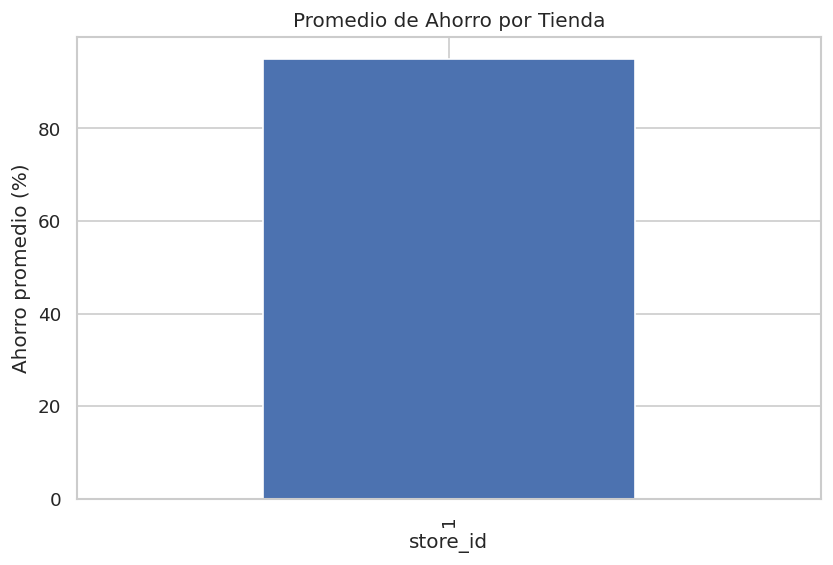

In [14]:
plt.figure(figsize=(8,5))
descuento_tienda.plot(kind='bar')
plt.title('Promedio de Ahorro por Tienda')
plt.xlabel('store_id')
plt.ylabel('Ahorro promedio (%)')
filename = os.path.join(graficas_dir, 'bar_promedio_ahorro_por_tienda.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

In [15]:
print('Promedio rating Steam:', df['rating_steam'].mean())
print('Promedio Metacritic:', df['metacritic'].mean())

print('\nCantidad de valores no nulos:')
print(df[['rating_steam', 'metacritic']].notnull().sum())

Promedio rating Steam: 75.0
Promedio Metacritic: 4.7

Cantidad de valores no nulos:
rating_steam    30
metacritic      30
dtype: int64


Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/scatter_rating_vs_ahorro.png


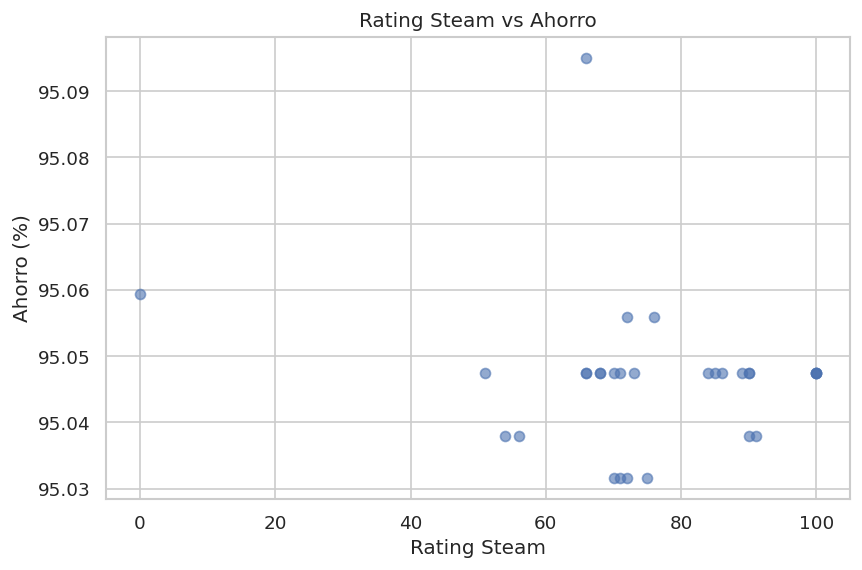

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(df['rating_steam'], df['ahorro_porcentaje'], alpha=0.6)
plt.title('Rating Steam vs Ahorro')
plt.xlabel('Rating Steam')
plt.ylabel('Ahorro (%)')
filename = os.path.join(graficas_dir, 'scatter_rating_vs_ahorro.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

In [17]:
df_modelo = df.dropna(subset=['precio_oferta', 'ahorro_porcentaje']).copy()

X = df_modelo[['precio_oferta']].values
y = df_modelo['ahorro_porcentaje'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print('Intercepto:', modelo.intercept_)
print('Coeficiente:', modelo.coef_[0])

Intercepto: 95.09896378281425
Coeficiente: -0.04935552928995961


In [18]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2: {r2:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')

R2: 0.7195
MSE: 0.0000
RMSE: 0.0033
MAE: 0.0028


Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/regresion_precio_vs_ahorro.png


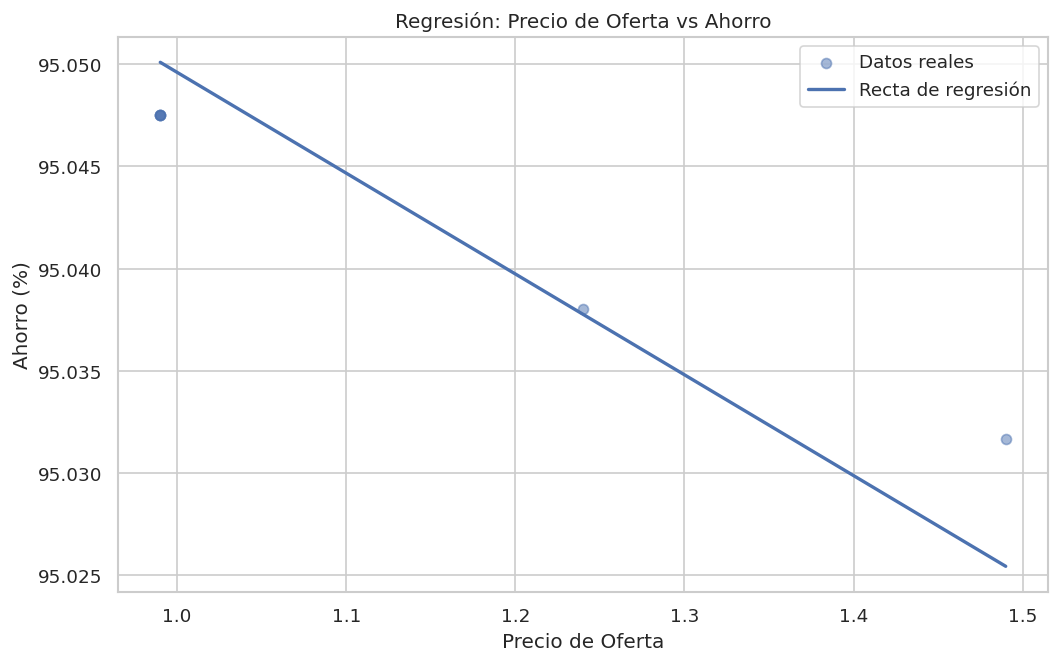

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(X_test, y_test, alpha=0.5, label='Datos reales')
plt.plot(np.sort(X_test.flatten()), modelo.predict(np.sort(X_test, axis=0)), linewidth=2, label='Recta de regresión')
plt.title('Regresión: Precio de Oferta vs Ahorro')
plt.xlabel('Precio de Oferta')
plt.ylabel('Ahorro (%)')
plt.legend()
filename = os.path.join(graficas_dir, 'regresion_precio_vs_ahorro.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

Gráfico guardado en: /home/zikocaklos/proyectos_mineria/ETL-JUEGOS-OFERTAS-Streamlit/data/graficas/residuos_regresion.png


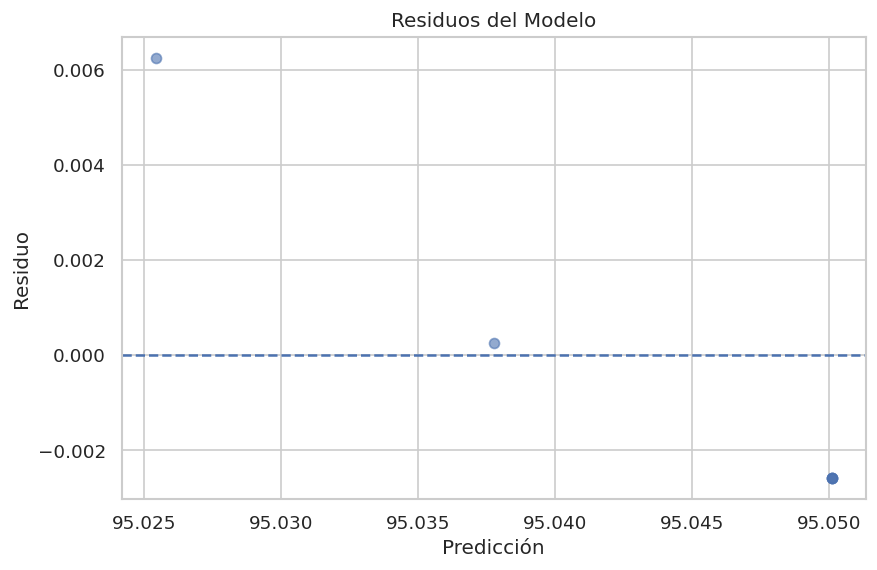

In [20]:
residuos = y_test - y_pred

plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuos, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title('Residuos del Modelo')
plt.xlabel('Predicción')
plt.ylabel('Residuo')
filename = os.path.join(graficas_dir, 'residuos_regresion.png')
plt.savefig(filename, dpi=150, bbox_inches='tight')
print(f'Gráfico guardado en: {filename}')
plt.show()

In [21]:
df_multi = df.dropna(subset=['precio_oferta', 'precio_normal', 'rating_steam', 'metacritic', 'ahorro_porcentaje']).copy()

X = df_multi[['precio_oferta', 'precio_normal', 'rating_steam', 'metacritic']]
y = df_multi['ahorro_porcentaje']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train)

y_pred_multi = modelo_multi.predict(X_test)

print('Intercepto:', modelo_multi.intercept_)
print('Coeficientes:')
for col, coef in zip(X.columns, modelo_multi.coef_):
    print(f'{col}: {coef:.4f}')

print('\nR2:', r2_score(y_test, y_pred_multi))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_multi)))
print('MAE:', mean_absolute_error(y_test, y_pred_multi))

Intercepto: 95.10184713407438
Coeficientes:
precio_oferta: -0.0001
precio_normal: -0.0024
rating_steam: -0.0000
metacritic: -0.0000

R2: 0.7661587371535816
RMSE: 0.0030224437384942324
MAE: 0.0023587961309180137


In [22]:
print('Conclusiones del análisis:')
print('- Se analizaron precios de oferta, precios normales y porcentaje de ahorro.')
print('- Se exploró la distribución de descuentos y precios.')
print('- Se evaluó la relación entre variables numéricas mediante correlación.')
print('- Se entrenó un modelo de regresión para predecir el ahorro porcentual.')
print('- También se comparó un modelo simple contra uno con múltiples variables.')

Conclusiones del análisis:
- Se analizaron precios de oferta, precios normales y porcentaje de ahorro.
- Se exploró la distribución de descuentos y precios.
- Se evaluó la relación entre variables numéricas mediante correlación.
- Se entrenó un modelo de regresión para predecir el ahorro porcentual.
- También se comparó un modelo simple contra uno con múltiples variables.
